In [3]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

In [4]:
df = pd.read_csv("/content/Combined.csv")
print(df.head())
print(df.columns)

                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  US Lawmaker: Ten ISIS Fighters Have Been Appre...   
2  Video shows ISIL beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین 9فروری کو روس میں بھی ...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody     Stance sentiment  
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی05 ...  unrelated  positive  
1  FORT DEVENS, Massachusetts -\n\nInfamous Bosto...  unrelated  negative  
2  KANSAS CITY, Mo. - Kansas City health official...  unrelated   neutral  
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی 07 ف...  unrelated  negative  
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...  unrelated   neutral  
Index(['Headline', 'articleBody', 'Stance', 'sentiment'], dtype='object')


In [5]:
df = df[['Headline', 'articleBody', 'sentiment']]

# Remove dates(digits) also as they does not make effect on sentiment detection and produce noise
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\u0600-\u06FF\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['Headline'] = df['Headline'].apply(clean_text)
df['articleBody'] = df['articleBody'].apply(clean_text)

print(df.head())

                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  us lawmaker ten isis fighters have been appreh...   
2  video shows isil beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین فروری کو روس میں بھی ر...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody sentiment  
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی ست...  positive  
1  fort devens massachusetts infamous boston mara...  negative  
2  kansas city mo kansas city health officials sa...   neutral  
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی فرور...  negative  
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...   neutral  


In [6]:
df['text'] = df['Headline'] + " " + df['articleBody']

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
print(label_encoder.classes_)

print(df.head())

['negative' 'neutral' 'positive']
                                            Headline  \
0      عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار   
1  us lawmaker ten isis fighters have been appreh...   
2  video shows isil beheading of photojournalist ...   
3  اکشے کمار کی فلم پیڈمین فروری کو روس میں بھی ر...   
4     فیس بک اسٹیٹس بڑے فو نٹ میں لکھنے کا سان طریقہ   

                                         articleBody sentiment  \
0  ممبئی اردو پوائنٹ اخبارتازہ ترین این این ئی ست...  positive   
1  fort devens massachusetts infamous boston mara...  negative   
2  kansas city mo kansas city health officials sa...   neutral   
3  ممبئی اردو پوائنٹ اخبارتازہ ترین اے پی پی فرور...  negative   
4  فیس بک میں ایک نئی تبدیلی ئی ہے جس کو تبدیل ہو...   neutral   

                                                text  label  
0  عمران ہاشمی ایشوریہ سے معذرت کرنے کے لیے تیار ...      2  
1  us lawmaker ten isis fighters have been appreh...      0  
2  video shows isil beheading of photojournali

In [7]:
# A simple tokenizer that builds a vocabulary and converts words to IDs.

def tokenize(text):
    return text.split()

tokenized_texts = [tokenize(t) for t in df['text']]

# Build vocabulary
all_words = [word for tokens in tokenized_texts for word in tokens]
vocab = Counter(all_words)
vocab = {word: i+2 for i, (word, _) in enumerate(vocab.items())}  # +2 to reserve 0,1 for PAD, OOV
vocab["<PAD>"] = 0
vocab["<OOV>"] = 1

# Convert words to numbers
def text_to_sequence(tokens, vocab):
    return [vocab.get(w, vocab["<OOV>"]) for w in tokens]

encoded_texts = [text_to_sequence(tokens, vocab) for tokens in tokenized_texts]

In [8]:
# Pad sequences to equal length as neural networks need same length inputs
max_len = 200

def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        return seq + [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        return seq[:max_len]

padded_texts = [pad_sequence(seq, max_len) for seq in encoded_texts]

In [9]:
# Split into train, validation and tests sets

X_train, X_temp, y_train, y_temp = train_test_split(
    padded_texts, df['label'],
    test_size=0.30,               # 30% goes to temp (val + test)
    random_state=42,
    stratify=df['label']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,               # half of 30% → 15%
    random_state=42,
    stratify=y_temp
)

print("Train set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

Train set size: 55986
Validation set size: 11997
Test set size: 11997


In [10]:
# For Loading data during training, make a simple class
class StanceDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_dataset = StanceDataset(X_train, y_train)
val_dataset = StanceDataset(X_val, y_val)
test_dataset = StanceDataset(X_test, y_test)

In [11]:
# DataLoader for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
# Using Pre-Trained Embeddings
import numpy as np

# Load GloVe embeddings (make sure glove.6B.100d.txt is downloaded in your path)
embeddings_index = {}
with open("/content/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word vectors.")

# Build embedding matrix
embedding_dim = 100  # same as GloVe dimension
embedding_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Loaded 400000 word vectors.
Embedding matrix shape: (192473, 100)


In [13]:
# Building the Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pretrained_embeddings=None):
        super(TextCNN, self).__init__()

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.conv1 = nn.Conv1d(embed_dim, 100, kernel_size=3)
        self.conv2 = nn.Conv1d(embed_dim, 100, kernel_size=4)
        self.conv3 = nn.Conv1d(embed_dim, 100, kernel_size=5)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x):
        x = self.embedding(x)          # [batch, seq_len, embed_dim]
        x = x.permute(0, 2, 1)         # [batch, embed_dim, seq_len]

        x1 = F.relu(self.conv1(x))
        x1 = F.max_pool1d(x1, x1.shape[2]).squeeze(2)

        x2 = F.relu(self.conv2(x))
        x2 = F.max_pool1d(x2, x2.shape[2]).squeeze(2)

        x3 = F.relu(self.conv3(x))
        x3 = F.max_pool1d(x3, x3.shape[2]).squeeze(2)

        x = torch.cat((x1, x2, x3), dim=1)
        x = self.dropout(x)
        return self.fc(x)


In [14]:
# Convert embedding matrix to tensor
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

# Initialize model
vocab_size = len(vocab)
embed_dim = 100
num_classes = len(label_encoder.classes_)

model = TextCNN(vocab_size, embed_dim, num_classes, pretrained_embeddings=embedding_matrix)
print(model)

TextCNN(
  (embedding): Embedding(192473, 100)
  (conv1): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
  (conv3): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=3, bias=True)
)


In [15]:
# Set up training tools

if torch.cuda.is_available():
    print("GPU is available")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available — using CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

No GPU available — using CPU


In [16]:
# Training Logic
# Also store loss and accuracy for each epoch
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

num_epochs = 3  # you can increase later
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # TRAINING
    model.train()                            # set model to training mode
    total_train_loss = 0
    all_preds, all_labels = [], []

    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()                # clear previous gradients
        outputs = model(texts)               # forward pass
        loss = criterion(outputs, labels)    # calculate loss
        loss.backward()                      # compute gradients
        optimizer.step()                     # update weights

        total_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # VALIDATION
    model.eval()
    total_val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/3 | Train Loss: 0.5411, Train Acc: 0.7413 | Val Loss: 0.4234, Val Acc: 0.7959
Epoch 2/3 | Train Loss: 0.3677, Train Acc: 0.8351 | Val Loss: 0.4240, Val Acc: 0.8008
Epoch 3/3 | Train Loss: 0.2561, Train Acc: 0.8947 | Val Loss: 0.4654, Val Acc: 0.8022


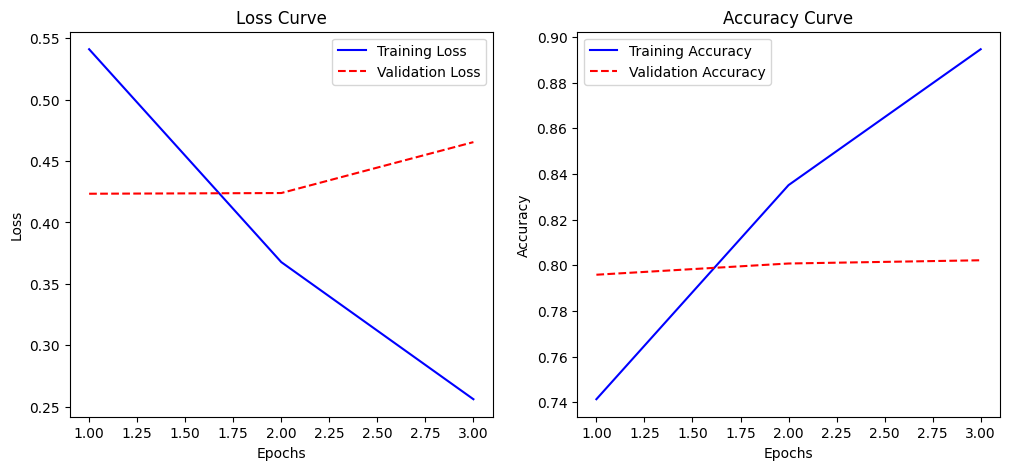

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, val_losses, 'r--', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r--', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      3713
     neutral       0.83      0.82      0.83      6338
    positive       0.66      0.65      0.66      1946

    accuracy                           0.80     11997
   macro avg       0.77      0.78      0.77     11997
weighted avg       0.80      0.80      0.80     11997



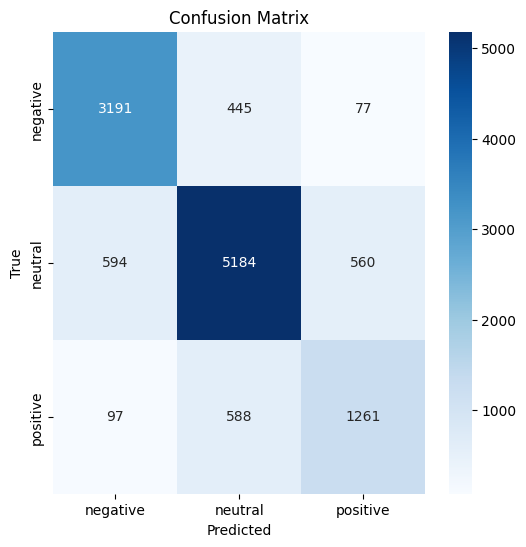

In [18]:
# Precision, Recall, F1-score, and Confusion Matrix

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Evaluate on test data
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Exact Match (EM) = how often the model predicts exactly the right class (same as accuracy in this case)

em_score = accuracy_score(test_labels, test_preds)
print(f"Exact Match (EM) Score: {em_score:.4f}")

Exact Match (EM) Score: 0.8032


In [20]:
# Save model, tokenizer, and label encoder
import torch
import pickle

# 1. Save model weights
torch.save(model.state_dict(), "CNN_Sentiment_model.pth")

# 2. Save tokenizer (vocab)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(vocab, f)

# 3. Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model, tokenizer, and label encoder saved successfully!")

Model, tokenizer, and label encoder saved successfully!


In [21]:
# Load tokenizer and label encoder

with open("tokenizer.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Rebuild the model structure
vocab_size = len(vocab)
embed_dim = 100
num_classes = len(label_encoder.classes_)

model = TextCNN(vocab_size, embed_dim, num_classes, pretrained_embeddings=embedding_matrix)

model.load_state_dict(torch.load("CNN_Sentiment_model.pth"))
model.eval()
print("Model loaded and ready for inference!")

Model loaded and ready for inference!


In [22]:
# Make predictions on new text
import torch.nn.functional as F

def predict_sentiment(headline, article, model, vocab, label_encoder, max_len=200):
    model.eval()
    with torch.no_grad():
        # Simple tokenization (same as before)
        tokens = (headline + " " + article).lower().split()
        seq = [vocab.get(token, vocab["<OOV>"]) for token in tokens]

        # Pad/truncate
        if len(seq) < max_len:
            seq += [vocab["<PAD>"]] * (max_len - len(seq))
        else:
            seq = seq[:max_len]

        # Convert to tensor
        input_tensor = torch.tensor([seq])

        # Predict
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        sentiment = label_encoder.classes_[pred_idx]

        return sentiment, probs[0][pred_idx].item()


In [28]:
# Example
headline = "Vaccine brings hope as infections drop and communities reopen"

article = """A wave of optimism is spreading across the country as vaccination rates continue to rise and infection numbers fall to their lowest levels in years.
Hospitals that were once overwhelmed are now reporting empty COVID wards, and doctors describe the change as “nothing short of a miracle.”

Families are finally reuniting after long months of separation, with children returning to classrooms and small businesses reopening their doors.
Health experts say the vaccine rollout has saved countless lives and restored public confidence.
The government has announced new programs to ensure booster doses reach remote communities, emphasizing that “every citizen deserves protection.”

Economists are also seeing the benefits — tourism, retail, and entertainment sectors have all shown steady growth, fueled by renewed public activity and optimism.
Local leaders say vaccination campaigns have not only strengthened healthcare systems but also inspired global cooperation and scientific innovation.

“The vaccine represents more than just medicine,” said WHO spokesperson Dr. Aisha Malik. “It symbolizes humanity’s ability to unite, adapt, and overcome the toughest challenges together.”

With new research showing strong long-term immunity and fewer variants emerging, experts remain hopeful that this marks the beginning of a sustained global recovery."""

pred, confidence = predict_sentiment(headline, article, model, vocab, label_encoder)
print(f"Predicted sentiment: {pred} (confidence: {confidence:.2f})")

Predicted stance: neutral (confidence: 0.73)
